In [1]:
import os
import torch
from torch.utils.data import random_split
import torchvision
import matplotlib.pyplot as plt
from deepinv.optim.data_fidelity import L2
from deepinv.models import BM3D
from deepinv.physics import Inpainting
from deepinv.optim.prior import PnP
from deepinv.optim.optimizers import optim_builder
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

In [2]:
# load MNIST dataset
size = 28
H, W = size, size
mnist_mean = 0.1307
mnist_var = 0.3081

# define the transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

# load the full MNIST dataset
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# calculate the split point (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# create train and validation subsets
clean_data_train_, clean_data_val_ = random_split(full_dataset, [train_size, val_size])

# reformat data to be tensors instead of lists
clean_data_train = torch.stack([data[0] for data in clean_data_train_])
clean_data_val = torch.stack([data[0] for data in clean_data_val_])

# construct noisy corrupted dataset
noise_level = 0.1
noisy_data_train = clean_data_train + noise_level * torch.randn_like(clean_data_train) 
noisy_data_val = clean_data_val + noise_level * torch.randn_like(clean_data_val) 

### Inpainting ###

In [3]:
# construct noisy corrupted dataset
img_shape = (1, H, W)    # For MNIST
mask_ratio = 0.7         # 70% observed pixels

# create an inpainting operator with a random mask (Bernoulli)
physics = Inpainting(tensor_size=img_shape, mask=mask_ratio)

In [4]:
# set up PnP solver
params_algo = {"stepsize": 0.99, "g_param": 0.4, "sigma": 0.99}
max_iter = 10
early_stop = True  # stop the algorithm when convergence is reached

# Select the data fidelity term
data_fidelity = L2()

# Specify the denoising prior
denoiser = BM3D()
prior = PnP(denoiser=denoiser)

# instantiate the algorithm class to solve the IP problem.
model = optim_builder(
    iteration="PGD",
    prior=prior,
    data_fidelity=data_fidelity,
    early_stop=early_stop,
    max_iter=max_iter,
    verbose=True,
    params_algo=params_algo,
)

In [5]:
# Plot original, noisy, and denoised images
def show_images(img_list, titles):
    fig, axes = plt.subplots(1, len(img_list), figsize=(12, 4))
    for i, (img, title) in enumerate(zip(img_list, titles)):
        axes[i].imshow(img[0].cpu().numpy().squeeze(), cmap="gray")
        axes[i].set_title(title)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

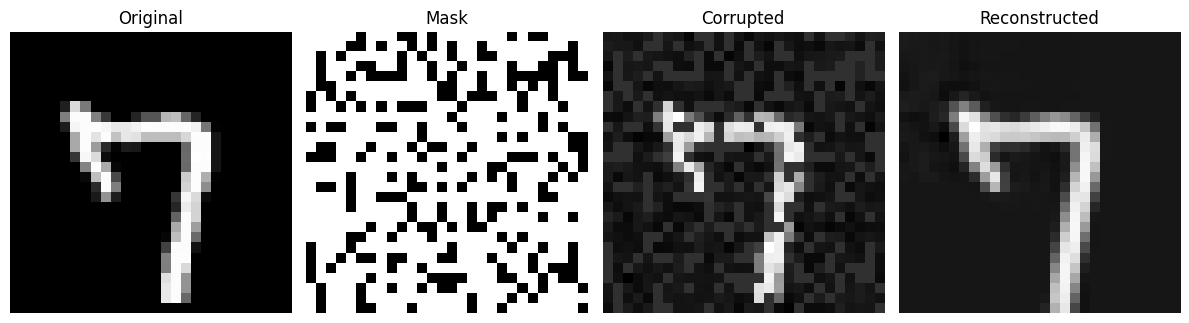

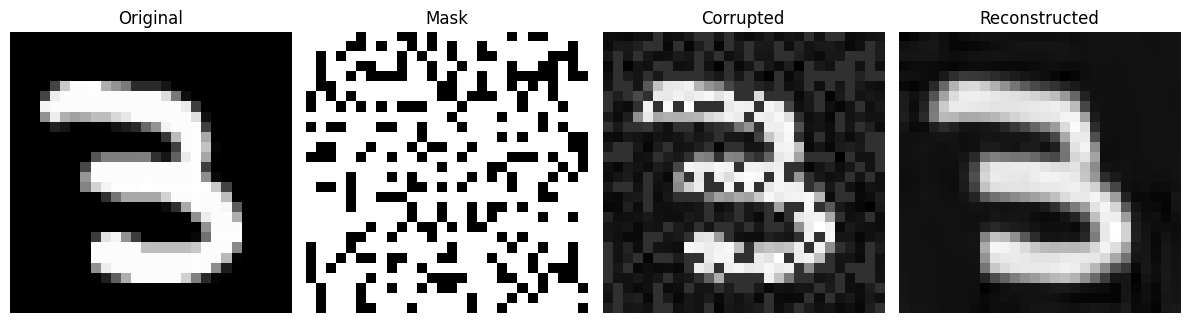

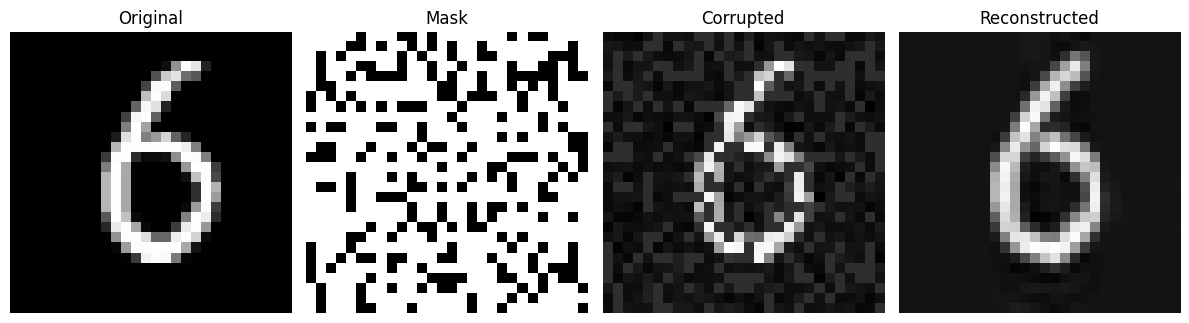

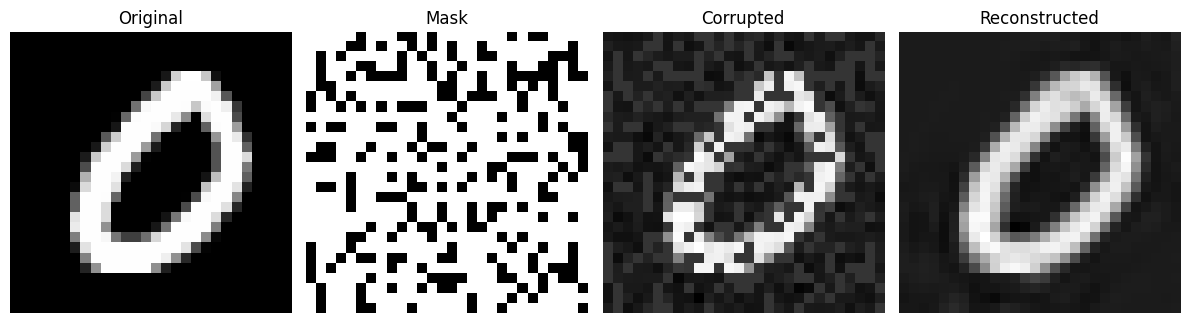

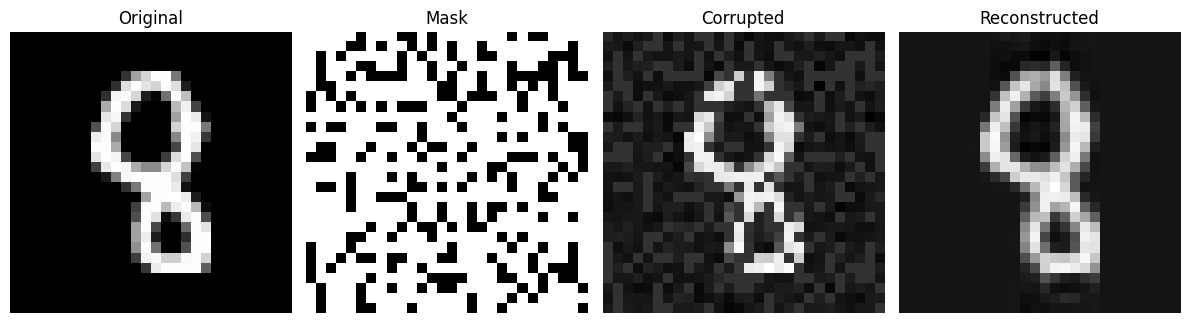

In [6]:
# test run 
num_tests = 5
y = physics(noisy_data_train[0:num_tests])  # observed pixels

# Run PnP to reconstruct
x_rec = model(y, physics)

# Show original, mask, corrupted, and reconstructed images
for i in range(num_tests):
    show_images(
            [clean_data_train[i], physics.mask, y[i], x_rec[i]],
            ["Original", "Mask", "Corrupted", "Reconstructed"]
        )

In [7]:
# construct the whole reconstructed data set for all corrupted images
folder_name = (
    f"mnist_inpainting_h{img_shape[1]}_w{img_shape[2]}_"
    f"mask{mask_ratio}_noise{noise_level}_"
    f"pgd_stepsize{params_algo['stepsize']}_g{params_algo['g_param']}_"
    f"sigma{params_algo['sigma']}_maxiter{max_iter}"
)
folder_path = os.path.join(".","data","MNIST","reconstructed",f"{folder_name}")
os.makedirs(folder_path, exist_ok=True)

checkpoint_interval = 100  # save every N steps

In [8]:
# find the latest chunk file
existing_chunks_train = [f for f in os.listdir(folder_path) if f.startswith("mnist_inpainting_pnp_train")]
if existing_chunks_train:
    print(max(existing_chunks_train, key=lambda x: int(x.split('_')[-1].split('.')[0])))
    last_chunk = max(existing_chunks_train, key=lambda x: int(x.split('_')[-1].split('.')[0]))
    chunk_end = int(last_chunk.split('_')[-1].split('.')[0]) + 1
    chunk_start = chunk_end - checkpoint_interval
    checkpoint = torch.load(os.path.join(folder_path, f"mnist_inpainting_pnp_train_{chunk_start}_{chunk_end-1}.pt"))
    start_idx = checkpoint['end_index'] + 1
    assert start_idx == chunk_end
else:
    start_idx = 0
print("start_idx:", start_idx)

cor_data_train = torch.zeros_like(noisy_data_train)
rec_data_train = torch.zeros_like(noisy_data_train)

for i in tqdm(range(start_idx, noisy_data_train.shape[0])):
    cor_data_train[i] = physics(noisy_data_train[i].cpu())
    rec_data_train[i] = model(cor_data_train[i], physics).cpu()

    if (i + 1) % checkpoint_interval == 0 or i == noisy_data_train.shape[0] - 1:
        end = i + 1
        start = end - checkpoint_interval
        save_dict = {
            'cor_data': cor_data_train[start:end].clone(),
            'rec_data': rec_data_train[start:end].clone(),
            'clean_data': clean_data_train[start:end].clone(),
            'mask': physics.mask,
            'start_index': start,
            'end_index': end - 1,
        }
        save_path = os.path.join(folder_path, f"mnist_inpainting_pnp_train_{start}_{end-1}.pt")
        torch.save(save_dict, save_path)
        print(f"Saved {save_path}")


mnist_inpainting_pnp_train_27700_27799.pt
start_idx: 27800


  0%|          | 2/20200 [00:07<21:23:33,  3.81s/it]


KeyboardInterrupt: 

In [8]:
# find the latest chunk file
existing_chunks_val = [f for f in os.listdir(folder_path) if f.startswith("mnist_inpainting_pnp_val")]
if existing_chunks_val:
    print(max(existing_chunks_val, key=lambda x: int(x.split('_')[-1].split('.')[0])))
    last_chunk = max(existing_chunks_val, key=lambda x: int(x.split('_')[-1].split('.')[0]))
    chunk_end = int(last_chunk.split('_')[-1].split('.')[0]) + 1
    chunk_start = chunk_end - checkpoint_interval
    checkpoint = torch.load(os.path.join(folder_path, f"mnist_inpainting_pnp_val_{chunk_start}_{chunk_end-1}.pt"))
    start_idx = checkpoint['end_index'] + 1
    assert start_idx == chunk_end
else:
    start_idx = 0
print("start_idx:", start_idx)

cor_data_val = torch.zeros_like(noisy_data_val)
rec_data_val = torch.zeros_like(noisy_data_val)

for i in tqdm(range(start_idx, noisy_data_val.shape[0])):
    cor_data_val[i] = physics(noisy_data_val[i].cpu())
    rec_data_val[i] = model(cor_data_val[i], physics).cpu()

    if (i + 1) % checkpoint_interval == 0 or i == noisy_data_val.shape[0] - 1:
        end = i + 1
        start = end - checkpoint_interval
        save_dict = {
            'cor_data': cor_data_val[start:end],
            'rec_data': rec_data_val[start:end],
            'clean_data': clean_data_val[start:end],
            'mask': physics.mask,
            'start_index': start,
            'end_index': end - 1,
        }
        save_path = os.path.join(folder_path, f"mnist_inpainting_pnp_val_{start}_{end-1}.pt")
        torch.save(save_dict, save_path)
        print(f"Saved {save_path}")


start_idx: 0


  1%|          | 100/12000 [06:57<13:49:35,  4.18s/it]

Saved ./data/MNIST/reconstructed/mnist_inpainting_h28_w28_mask0.7_noise0.1_pgd_stepsize[0.99]_g[0.4]_sigma[0.99]_maxiter10/mnist_inpainting_pnp_val_0_99.pt


  1%|          | 100/12000 [07:01<13:55:17,  4.21s/it]


KeyboardInterrupt: 